# DS605 - Airbnb Price Prediction

## End-to-End Machine Learning Project

This project builds an end-to-end machine learning workflow for predicting
Airbnb nightly prices using the New York City Airbnb Open Data dataset.

### Objectives
- Perform data analysis and cleaning
- Handle missing values and outliers
- Perform feature engineering and feature selection
- Compare regression models
- Perform hyperparameter tuning
- Evaluate the final model
- Save the trained preprocessing and prediction pipeline
- Deploy the model using Streamlit

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

# ============================================================
# LOAD DATA
# ============================================================

DATA_PATH = Path("../data/AB_NYC_2019.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

df.head()

Dataset loaded successfully!
Dataset shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [105]:
# ============================================================
# BASIC DATASET INFORMATION
# ============================================================

print("Dataset Information")
print("=" * 60)

print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]:,}")

print("\nColumn Names")
print("=" * 60)

print(df.columns.tolist())

print("\nData Types")
print("=" * 60)

print(df.dtypes)

Dataset Information
Number of rows    : 48,895
Number of columns : 16

Column Names
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data Types
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365   

In [106]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [107]:
# ============================================================
# MISSING VALUES
# ============================================================

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_values = missing_values[
    missing_values["Missing Count"] > 0
].sort_values(
    "Missing Percentage",
    ascending=False
)

missing_values

,Missing Count,Missing Percentage
reviews_per_month,10052,20.56
last_review,10052,20.56
host_name,21,0.04
name,16,0.03


In [108]:
# ============================================================
# DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


## 2. Data Cleaning

The Airbnb dataset contains missing values and potentially unrealistic
observations. Before modelling, the data will be cleaned by:

- Removing listings with invalid or zero prices
- Examining extreme price values
- Handling missing values in relevant variables
- Preparing a clean dataset for further analysis

In [109]:
# ============================================================
# CHECK TARGET VARIABLE: PRICE
# ============================================================

print("Price Summary")
print("=" * 60)

print(df["price"].describe())

print("\nNumber of zero-price listings:")
print((df["price"] == 0).sum())

print("\nNumber of negative-price listings:")
print((df["price"] < 0).sum())

Price Summary
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Number of zero-price listings:
11

Number of negative-price listings:
0


In [110]:
# ============================================================
# REMOVE INVALID PRICE VALUES
# ============================================================

before_rows = len(df)

df = df[df["price"] > 0].copy()

after_rows = len(df)

print(f"Rows before removing invalid prices: {before_rows:,}")
print(f"Rows after removing invalid prices : {after_rows:,}")
print(f"Rows removed                       : {before_rows - after_rows:,}")

Rows before removing invalid prices: 48,895
Rows after removing invalid prices : 48,884
Rows removed                       : 11


In [111]:
# ============================================================
# CHECK EXTREME PRICE VALUES
# ============================================================

print("Highest Airbnb prices:")
print(df["price"].sort_values(ascending=False).head(20).to_list())

Highest Airbnb prices:
[10000, 10000, 10000, 9999, 9999, 9999, 8500, 8000, 7703, 7500, 7500, 6800, 6500, 6500, 6500, 6419, 6000, 6000, 5250, 5100]


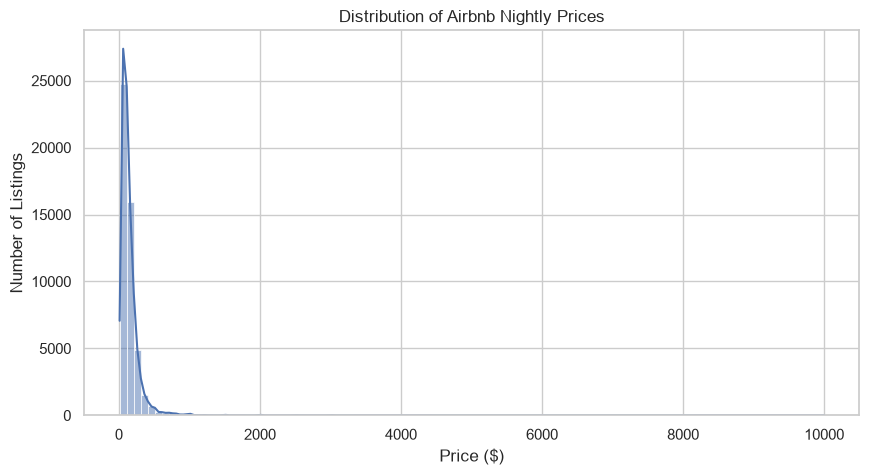

In [112]:
# ============================================================
# VISUALIZE PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    df["price"],
    bins=100,
    kde=True
)

plt.title("Distribution of Airbnb Nightly Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

In [113]:
# ============================================================
# CHECK MISSING VALUES AFTER INITIAL CLEANING
# ============================================================

missing_after_cleaning = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_after_cleaning = missing_after_cleaning[
    missing_after_cleaning["Missing Count"] > 0
].sort_values(
    "Missing Percentage",
    ascending=False
)

missing_after_cleaning

,Missing Count,Missing Percentage
reviews_per_month,10051,20.56
last_review,10051,20.56
host_name,21,0.04
name,16,0.03


In [114]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

# Reviews per month:
# Missing values indicate that the listing has no recorded reviews.
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# Last review:
# Missing values indicate that the listing has no recorded review.
df["last_review"] = df["last_review"].fillna("No Review")

# Check remaining missing values
remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

print("Remaining missing values:")
print(remaining_missing)

Remaining missing values:
name         16
host_name    21
dtype: int64


In [115]:
# ============================================================
# FINAL CLEANING CHECK
# ============================================================

print("Clean Dataset Summary")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nFirst 5 rows:")
display(df.head())

Clean Dataset Summary
Rows    : 48,884
Columns : 16

Total missing values:
37

First 5 rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Exploratory Data Analysis

Exploratory data analysis is performed to understand the distribution of
Airbnb listings and identify relationships between listing characteristics
and nightly price.

The analysis focuses on:
- Price distribution
- Room type
- Neighbourhood group
- Number of reviews
- Availability
- Relationship between numerical features and price

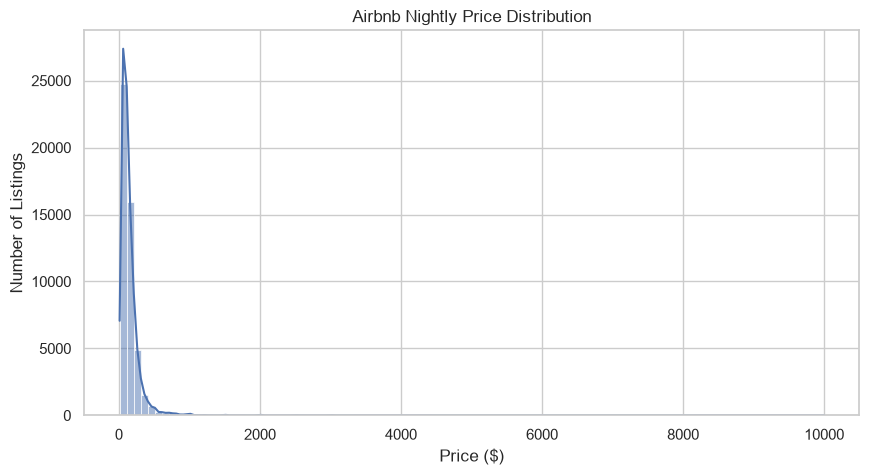

In [116]:
# ============================================================
# PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    df["price"],
    bins=100,
    kde=True
)

plt.title("Airbnb Nightly Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

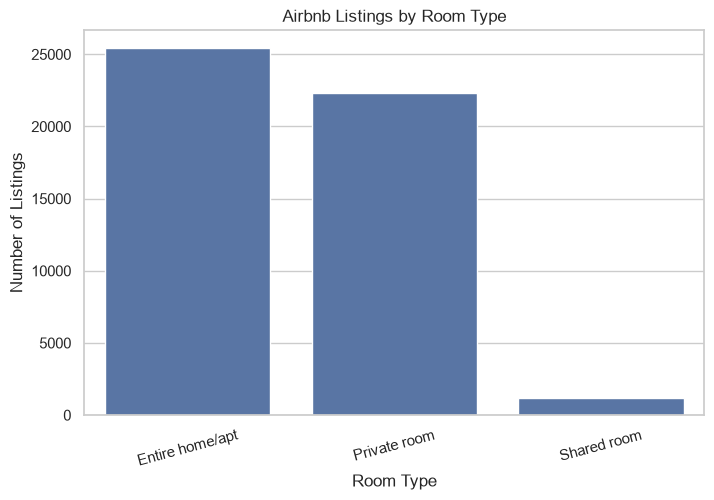

In [117]:
# ============================================================
# ROOM TYPE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="room_type",
    order=df["room_type"].value_counts().index
)

plt.title("Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.xticks(rotation=15)

plt.show()

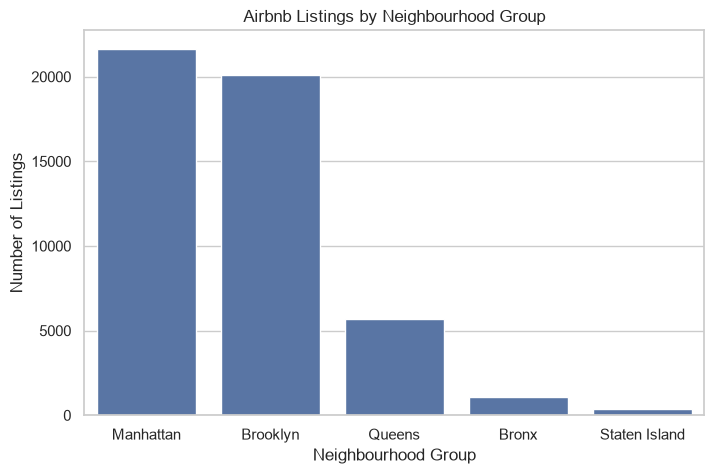

In [118]:
# ============================================================
# NEIGHBOURHOOD GROUP DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="neighbourhood_group",
    order=df["neighbourhood_group"].value_counts().index
)

plt.title("Airbnb Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")

plt.show()

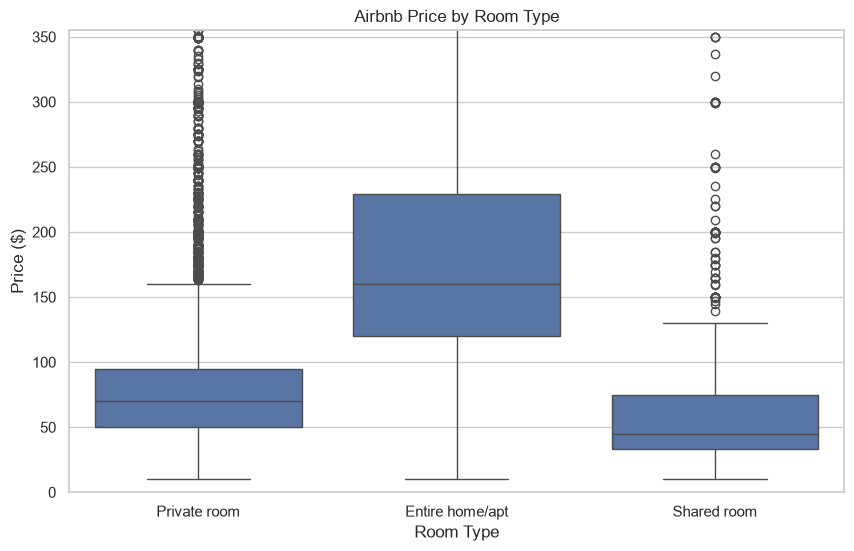

In [119]:
# ============================================================
# PRICE BY ROOM TYPE
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.title("Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")

plt.ylim(0, df["price"].quantile(0.95))

plt.show()

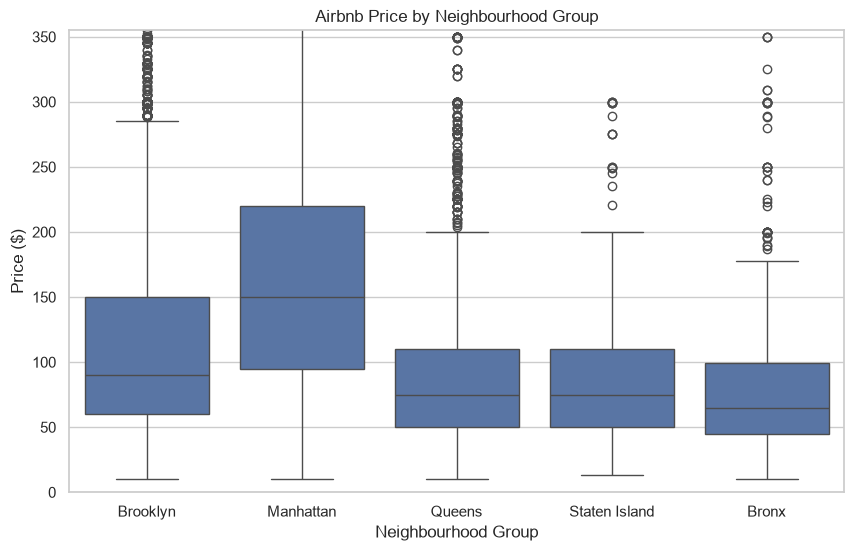

In [120]:
# ============================================================
# PRICE BY NEIGHBOURHOOD GROUP
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="neighbourhood_group",
    y="price"
)

plt.title("Airbnb Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price ($)")

plt.ylim(0, df["price"].quantile(0.95))

plt.show()

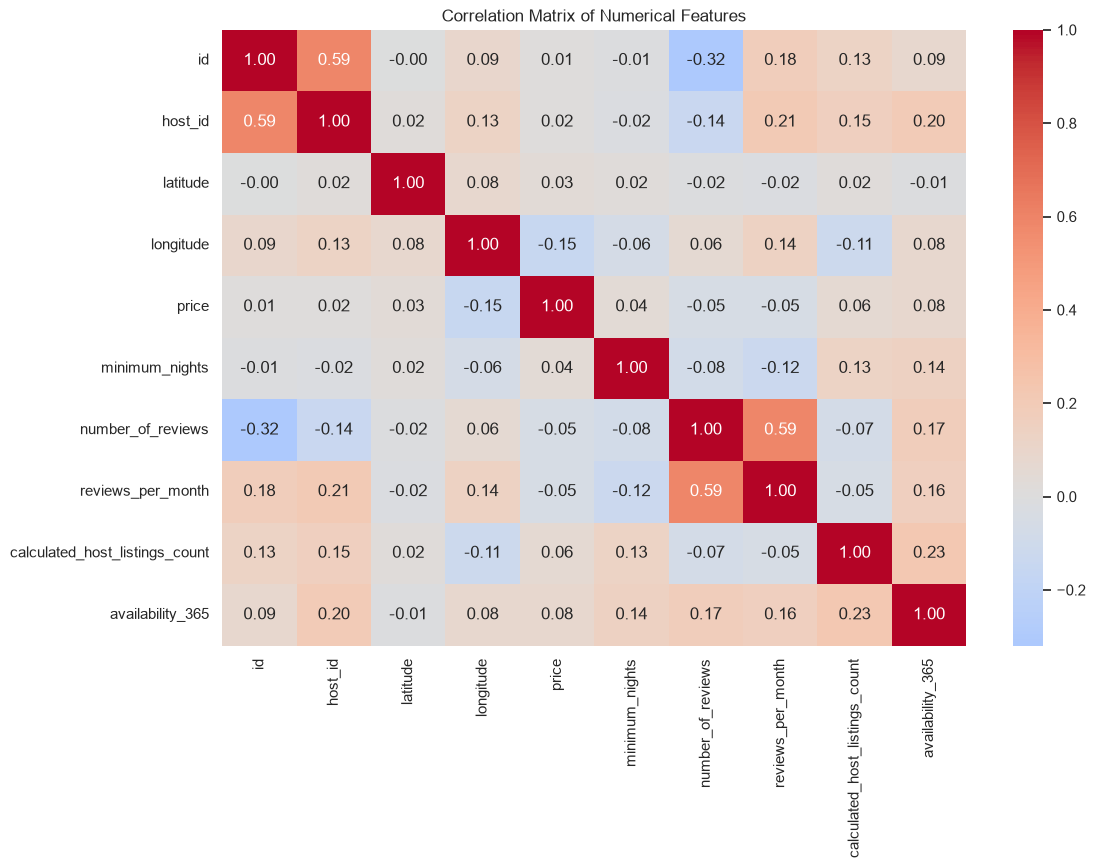

In [121]:
# ============================================================
# NUMERICAL FEATURE CORRELATION
# ============================================================

numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

correlation = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [122]:
# ============================================================
# AVERAGE PRICE BY ROOM TYPE
# ============================================================

room_price_summary = (
    df.groupby("room_type")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

room_price_summary

,count,mean,median
room_type,,,
Entire home/apt,25407,211.810918,160.0
Private room,22319,89.809131,70.0
Shared room,1158,70.248705,45.0


In [123]:
# ============================================================
# AVERAGE PRICE BY NEIGHBOURHOOD GROUP
# ============================================================

neighbourhood_price_summary = (
    df.groupby("neighbourhood_group")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

neighbourhood_price_summary 

,count,mean,median
neighbourhood_group,,,
Manhattan,21660,196.884903,150.0
Brooklyn,20095,124.438915,90.0
Staten Island,373,114.812332,75.0
Queens,5666,99.517649,75.0
Bronx,1090,87.577064,65.0


## 4. Feature Engineering and Feature Selection

Additional features are created to capture useful information from the
original Airbnb variables.

The engineered features include:
- Total reviews
- Availability ratio
- Log-transformed minimum nights
- Log-transformed number of reviews
- Log-transformed availability

Identifiers and unnecessary text fields are removed because they are not
useful for predicting nightly price.

In [124]:
import numpy as np
import pandas as pd
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Total reviews
df["total_reviews"] = df["number_of_reviews"]


# Availability ratio
df["availability_ratio"] = (
    df["availability_365"] / 365
)


# Log transformations
df["minimum_nights_log"] = np.log1p(
    df["minimum_nights"]
)

df["number_of_reviews_log"] = np.log1p(
    df["number_of_reviews"]
)

df["availability_365_log"] = np.log1p(
    df["availability_365"]
)


# ============================================================
# REMOVE UNUSED COLUMNS
# ============================================================

columns_to_drop = [
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review"
]

df = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)


# ============================================================
# CHECK RESULT
# ============================================================

print("Dataset shape after feature engineering:", df.shape)

print("\nRemaining columns:")
print(df.columns.tolist())

Dataset shape after feature engineering: (48884, 16)

Remaining columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'total_reviews', 'availability_ratio', 'minimum_nights_log', 'number_of_reviews_log', 'availability_365_log']


In [125]:
# Step 5: Define Features and Target

X = df.drop(columns=["price"])
y = df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (48884, 15)
Target shape: (48884,)

Feature columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'total_reviews', 'availability_ratio', 'minimum_nights_log', 'number_of_reviews_log', 'availability_365_log']


In [126]:
# Step 6: Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (39107, 15)
Testing features: (9777, 15)
Training target: (39107,)
Testing target: (9777,)


In [127]:
# Step 7: Define numerical and categorical features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "review_year",
    "review_month",
    "review_days_old",
    "total_reviews",
    "availability_ratio",
    "minimum_nights_log",
    "number_of_reviews_log",
    "availability_365_log"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 3
Numerical features: 15


In [128]:
# Step 8: Create preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [129]:
# Fix missing review date features

# Reload original dataset
df_original = pd.read_csv("../data/AB_NYC_2019.csv")

# Convert last_review to datetime
df_original["last_review"] = pd.to_datetime(
    df_original["last_review"],
    errors="coerce"
)

# Create review date features
df["review_year"] = df_original["last_review"].dt.year.fillna(0).astype(int)
df["review_month"] = df_original["last_review"].dt.month.fillna(0).astype(int)

# Calculate how many days since the last review
reference_date = df_original["last_review"].max()

df["review_days_old"] = (
    reference_date - df_original["last_review"]
).dt.days.fillna(9999)

print("Review date features created successfully.")

print(
    df[
        ["review_year", "review_month", "review_days_old"]
    ].head()
)

print("\nNew dataset shape:", df.shape)

Review date features created successfully.
   review_year  review_month  review_days_old
0         2018            10            262.0
1         2019             5             48.0
2            0             0           9999.0
3         2019             7              3.0
4         2018            11            231.0

New dataset shape: (48884, 19)


In [130]:
# Verify the review date features

required_features = [
    "review_year",
    "review_month",
    "review_days_old"
]

print("Checking required features:\n")

for feature in required_features:
    print(f"{feature}: {feature in df.columns}")

Checking required features:

review_year: True
review_month: True
review_days_old: True


In [131]:
# Step 10: Refresh features and train/test split

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Updated X shape:", X.shape)
print("Updated X_train shape:", X_train.shape)
print("Updated X_test shape:", X_test.shape)

print("\nChecking review features in X:")
print([
    "review_year" in X.columns,
    "review_month" in X.columns,
    "review_days_old" in X.columns
])

Updated X shape: (48884, 18)
Updated X_train shape: (39107, 18)
Updated X_test shape: (9777, 18)

Checking review features in X:
[True, True, True]


In [132]:
# Step 11: Update numerical features

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "review_year",
    "review_month",
    "review_days_old",
    "total_reviews",
    "availability_ratio",
    "minimum_nights_log",
    "number_of_reviews_log",
    "availability_365_log"
]

print("Numerical features:", len(numerical_features))
print(numerical_features)

Numerical features: 15
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'review_year', 'review_month', 'review_days_old', 'total_reviews', 'availability_ratio', 'minimum_nights_log', 'number_of_reviews_log', 'availability_365_log']


In [133]:
# Step 12: Recreate preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline updated successfully.")

Preprocessing pipeline updated successfully.


In [134]:
# Step 13: Train Linear Regression Model

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

NameError: name 'LinearRegression' is not defined

In [ ]:
# Step 14: Create the final preprocessing pipeline

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("FINAL preprocessing pipeline created successfully.")

FINAL preprocessing pipeline created successfully.


In [ ]:
# Step 15: Train Linear Regression Model

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# Step 16: Evaluate Linear Regression Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Linear Regression Results")
print("-" * 40)

print(f"Train MAE  : {train_mae:.2f}")
print(f"Test MAE   : {test_mae:.2f}")

print(f"Train RMSE : {train_rmse:.2f}")
print(f"Test RMSE  : {test_rmse:.2f}")

print(f"Train R²   : {train_r2:.4f}")
print(f"Test R²    : {test_r2:.4f}")

Linear Regression Results
----------------------------------------
Train MAE  : 71.99
Test MAE   : 71.17
Train RMSE : 233.45
Test RMSE  : 184.59
Train R²   : 0.1223
Test R²    : 0.1489


In [ ]:
# Step 17: Train Random Forest Regression Model

from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=20,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Step 18: Evaluate Random Forest Model

y_train_pred_rf = random_forest_model.predict(X_train)
y_test_pred_rf = random_forest_model.predict(X_test)

# Training metrics
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
train_r2_rf = r2_score(y_train, y_train_pred_rf)

# Testing metrics
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("Random Forest Results")
print("-" * 40)

print(f"Train MAE  : {train_mae_rf:.2f}")
print(f"Test MAE   : {test_mae_rf:.2f}")

print(f"Train RMSE : {train_rmse_rf:.2f}")
print(f"Test RMSE  : {test_rmse_rf:.2f}")

print(f"Train R²   : {train_r2_rf:.4f}")
print(f"Test R²    : {test_r2_rf:.4f}")

Random Forest Results
----------------------------------------
Train MAE  : 35.30
Test MAE   : 66.73
Train RMSE : 96.22
Test RMSE  : 195.81
Train R²   : 0.8509
Test R²    : 0.0423


In [ ]:
# Step 19: Compare Regression Models

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "Train MAE": [
        train_mae,
        train_mae_rf
    ],
    "Test MAE": [
        test_mae,
        test_mae_rf
    ],
    "Train RMSE": [
        train_rmse,
        train_rmse_rf
    ],
    "Test RMSE": [
        test_rmse,
        test_rmse_rf
    ],
    "Train R²": [
        train_r2,
        train_r2_rf
    ],
    "Test R²": [
        test_r2,
        test_r2_rf
    ]
})

model_comparison

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Linear Regression,71.993171,71.174423,233.450164,184.588226,0.122272,0.148945
1,Random Forest,35.299836,66.726011,96.215006,195.807913,0.850907,0.042342


In [ ]:
# Step 20: Check for overfitting

print("R² Comparison")
print("-" * 40)

print(f"Linear Regression:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R² : {test_r2:.4f}")
print(f"  R² Gap  : {train_r2 - test_r2:.4f}")

print()

print(f"Random Forest:")
print(f"  Train R²: {train_r2_rf:.4f}")
print(f"  Test R² : {test_r2_rf:.4f}")
print(f"  R² Gap  : {train_r2_rf - test_r2_rf:.4f}")

R² Comparison
----------------------------------------
Linear Regression:
  Train R²: 0.1223
  Test R² : 0.1489
  R² Gap  : -0.0267

Random Forest:
  Train R²: 0.8509
  Test R² : 0.0423
  R² Gap  : 0.8086


In [ ]:
# Step 21: Select the best model based on test performance

best_model_name = model_comparison.loc[
    model_comparison["Test R²"].idxmax(),
    "Model"
]

print("Best model:", best_model_name)

Best model: Linear Regression


In [135]:
# Step 22: Hyperparameter tuning using Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid_ridge,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

print("Best Ridge parameters:")
print(ridge_search.best_params_)

print("\nBest CV RMSE:")
print(-ridge_search.best_score_)

Best Ridge parameters:
{'model__alpha': 10}

Best CV RMSE:
232.8421079596648


In [137]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Step 23: Final evaluation of tuned Ridge Regression

best_model = ridge_search.best_estimator_

# Predictions
y_train_pred_final = best_model.predict(X_train)
y_test_pred_final = best_model.predict(X_test)

# Metrics
final_train_mae = mean_absolute_error(y_train, y_train_pred_final)
final_test_mae = mean_absolute_error(y_test, y_test_pred_final)

final_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_final)
)
final_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_final)
)

final_train_r2 = r2_score(y_train, y_train_pred_final)
final_test_r2 = r2_score(y_test, y_test_pred_final)

print("FINAL TUNED RIDGE REGRESSION RESULTS")
print("-" * 45)

print(f"Train MAE  : {final_train_mae:.2f}")
print(f"Test MAE   : {final_test_mae:.2f}")

print(f"Train RMSE : {final_train_rmse:.2f}")
print(f"Test RMSE  : {final_test_rmse:.2f}")

print(f"Train R²   : {final_train_r2:.4f}")
print(f"Test R²    : {final_test_r2:.4f}")

print(f"\nR² Gap     : {final_train_r2 - final_test_r2:.4f}")

FINAL TUNED RIDGE REGRESSION RESULTS
---------------------------------------------
Train MAE  : 71.86
Test MAE   : 70.86
Train RMSE : 233.57
Test RMSE  : 184.23
Train R²   : 0.1214
Test R²    : 0.1522

R² Gap     : -0.0308


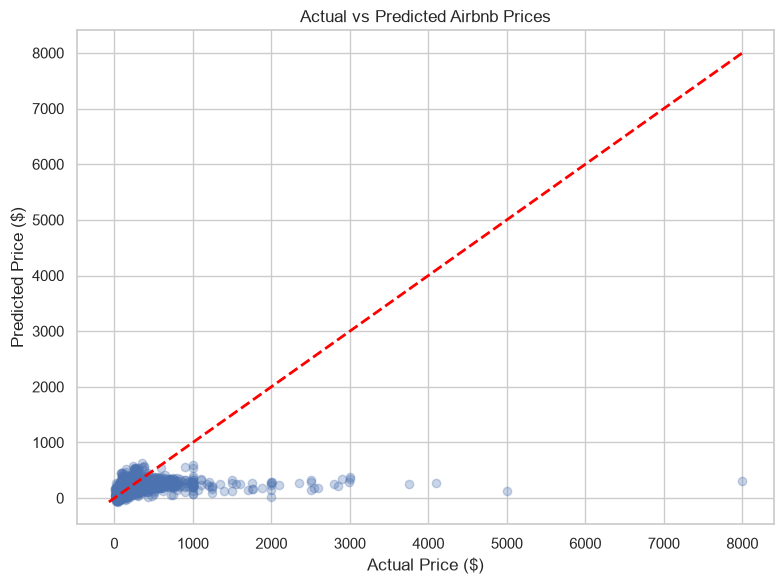

In [138]:
# Step 24: Actual vs Predicted Price Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred_final,
    alpha=0.3
)

# Perfect prediction line
min_price = min(y_test.min(), y_test_pred_final.min())
max_price = max(y_test.max(), y_test_pred_final.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")

plt.tight_layout()
plt.show()